# Newsroom — Analysis

Models:
- Mistral
- LLaMA
- GPT-4o

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import pandas as pd
pd.set_option('display.max_columns', None) # display all columns

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## Read Data

In [14]:
# Load preprocessed data (run preprocessing.ipynb first if needed)
df = pd.read_csv('../data/newsroom_judged_cleaned.csv')

print(f"Loaded cleaned dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded cleaned dataset shape: (327, 24)
Columns: ['GPT-4o_informativeness_as_a_judge', 'GPT-4o_relevance_as_a_judge', 'GPT-4o_fluency_as_a_judge', 'GPT-4o_coherence_as_a_judge', 'Llama_informativeness_as_a_judge', 'Llama_relevance_as_a_judge', 'Llama_fluency_as_a_judge', 'Llama_coherence_as_a_judge', 'Mistral_informativeness_as_a_judge', 'Mistral_relevance_as_a_judge', 'Mistral_fluency_as_a_judge', 'Mistral_coherence_as_a_judge', 'informativeness_human_#1', 'informativeness_human_#2', 'informativeness_human_#3', 'relevance_human_#1', 'relevance_human_#2', 'relevance_human_#3', 'fluency_human_#1', 'fluency_human_#2', 'fluency_human_#3', 'coherence_human_#1', 'coherence_human_#2', 'coherence_human_#3']


,GPT-4o_informativeness_as_a_judge,GPT-4o_relevance_as_a_judge,GPT-4o_fluency_as_a_judge,GPT-4o_coherence_as_a_judge,Llama_informativeness_as_a_judge,Llama_relevance_as_a_judge,Llama_fluency_as_a_judge,Llama_coherence_as_a_judge,Mistral_informativeness_as_a_judge,Mistral_relevance_as_a_judge,Mistral_fluency_as_a_judge,Mistral_coherence_as_a_judge,informativeness_human_#1,informativeness_human_#2,informativeness_human_#3,relevance_human_#1,relevance_human_#2,relevance_human_#3,fluency_human_#1,fluency_human_#2,fluency_human_#3,coherence_human_#1,coherence_human_#2,coherence_human_#3
0,1,1,1,1,2,2,1,2,4.0,1.0,2,1,3,1,1,4,1,1,5,3,1,5,1,1
1,1,1,1,1,2,2,2,3,4.0,3.0,4,3,3,1,4,4,2,3,4,3,3,4,1,4
2,1,1,2,1,2,2,2,2,5.0,5.0,4,4,2,1,5,2,5,4,3,5,5,2,2,5
3,1,1,2,1,2,2,2,3,3.0,4.0,3,2,5,2,4,4,4,4,5,4,2,5,4,3
4,1,1,1,1,1,1,1,1,1.0,1.0,4,2,5,3,4,4,2,3,5,2,4,5,2,5


In [15]:
# Define column groups and score range for analysis
MIN, MAX = 1, 5

# Human columns by metric
human_informative_cols = [col for col in df.columns if 'informativeness_human_' in col]
human_relevance_cols   = [col for col in df.columns if 'relevance_human_' in col]
human_fluency_cols     = [col for col in df.columns if 'fluency_human_' in col]
human_coherence_cols   = [col for col in df.columns if 'coherence_human_' in col]

# LLM columns by metric
llm_informative_cols = [col for col in df.columns if 'informativeness_as_a_judge' in col]
llm_relevance_cols   = [col for col in df.columns if 'relevance_as_a_judge' in col]
llm_fluency_cols     = [col for col in df.columns if 'fluency_as_a_judge' in col]
llm_coherence_cols   = [col for col in df.columns if 'coherence_as_a_judge' in col]

print(f"Score range: [{MIN}, {MAX}]")
print(f"\nHuman columns:")
print(f"  Informativeness: {human_informative_cols}")
print(f"  Relevance: {human_relevance_cols}")
print(f"  Fluency: {human_fluency_cols}")
print(f"  Coherence: {human_coherence_cols}")
print(f"\nLLM columns:")
print(f"  Informativeness: {llm_informative_cols}")
print(f"  Relevance: {llm_relevance_cols}")
print(f"  Fluency: {llm_fluency_cols}")
print(f"  Coherence: {llm_coherence_cols}")

Score range: [1, 5]

Human columns:
  Informativeness: ['informativeness_human_#1', 'informativeness_human_#2', 'informativeness_human_#3']
  Relevance: ['relevance_human_#1', 'relevance_human_#2', 'relevance_human_#3']
  Fluency: ['fluency_human_#1', 'fluency_human_#2', 'fluency_human_#3']
  Coherence: ['coherence_human_#1', 'coherence_human_#2', 'coherence_human_#3']

LLM columns:
  Informativeness: ['GPT-4o_informativeness_as_a_judge', 'Llama_informativeness_as_a_judge', 'Mistral_informativeness_as_a_judge']
  Relevance: ['GPT-4o_relevance_as_a_judge', 'Llama_relevance_as_a_judge', 'Mistral_relevance_as_a_judge']
  Fluency: ['GPT-4o_fluency_as_a_judge', 'Llama_fluency_as_a_judge', 'Mistral_fluency_as_a_judge']
  Coherence: ['GPT-4o_coherence_as_a_judge', 'Llama_coherence_as_a_judge', 'Mistral_coherence_as_a_judge']


## Instances

In [16]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

from core.llm_good_enough import LLMGoodEnough

SEED = 47

# Initialize evaluators for each metric
good_enough_informativeness = LLMGoodEnough(
    df=df,
    human_cols=human_informative_cols,
    llm_cols=llm_informative_cols,
    min_score=MIN,
    max_score=MAX,
    seed=SEED,
    verbosity=0
)
good_enough_relevance = LLMGoodEnough(
    df=df,
    human_cols=human_relevance_cols,
    llm_cols=llm_relevance_cols,
    min_score=MIN,
    max_score=MAX,
    seed=SEED,
    verbosity=0
)
good_enough_fluency = LLMGoodEnough(
    df=df,
    human_cols=human_fluency_cols,
    llm_cols=llm_fluency_cols,
    min_score=MIN,
    max_score=MAX,
    seed=SEED,
    verbosity=0
)
good_enough_coherence = LLMGoodEnough(
    df=df,
    human_cols=human_coherence_cols,
    llm_cols=llm_coherence_cols,
    min_score=MIN,
    max_score=MAX,
    seed=SEED,
    verbosity=0
)

## Results

**Hypotheses (MWU, one-sided `alternative="greater"`):**
- **H₀:** LLM–Human disagreement is not greater than Human–Human disagreement.
- **H₁:** LLM–Human disagreement is greater.

### Informativeness

✅ Figure saved as PDF → ../figures/pdf/newsroom_informativeness_barplot.pdf


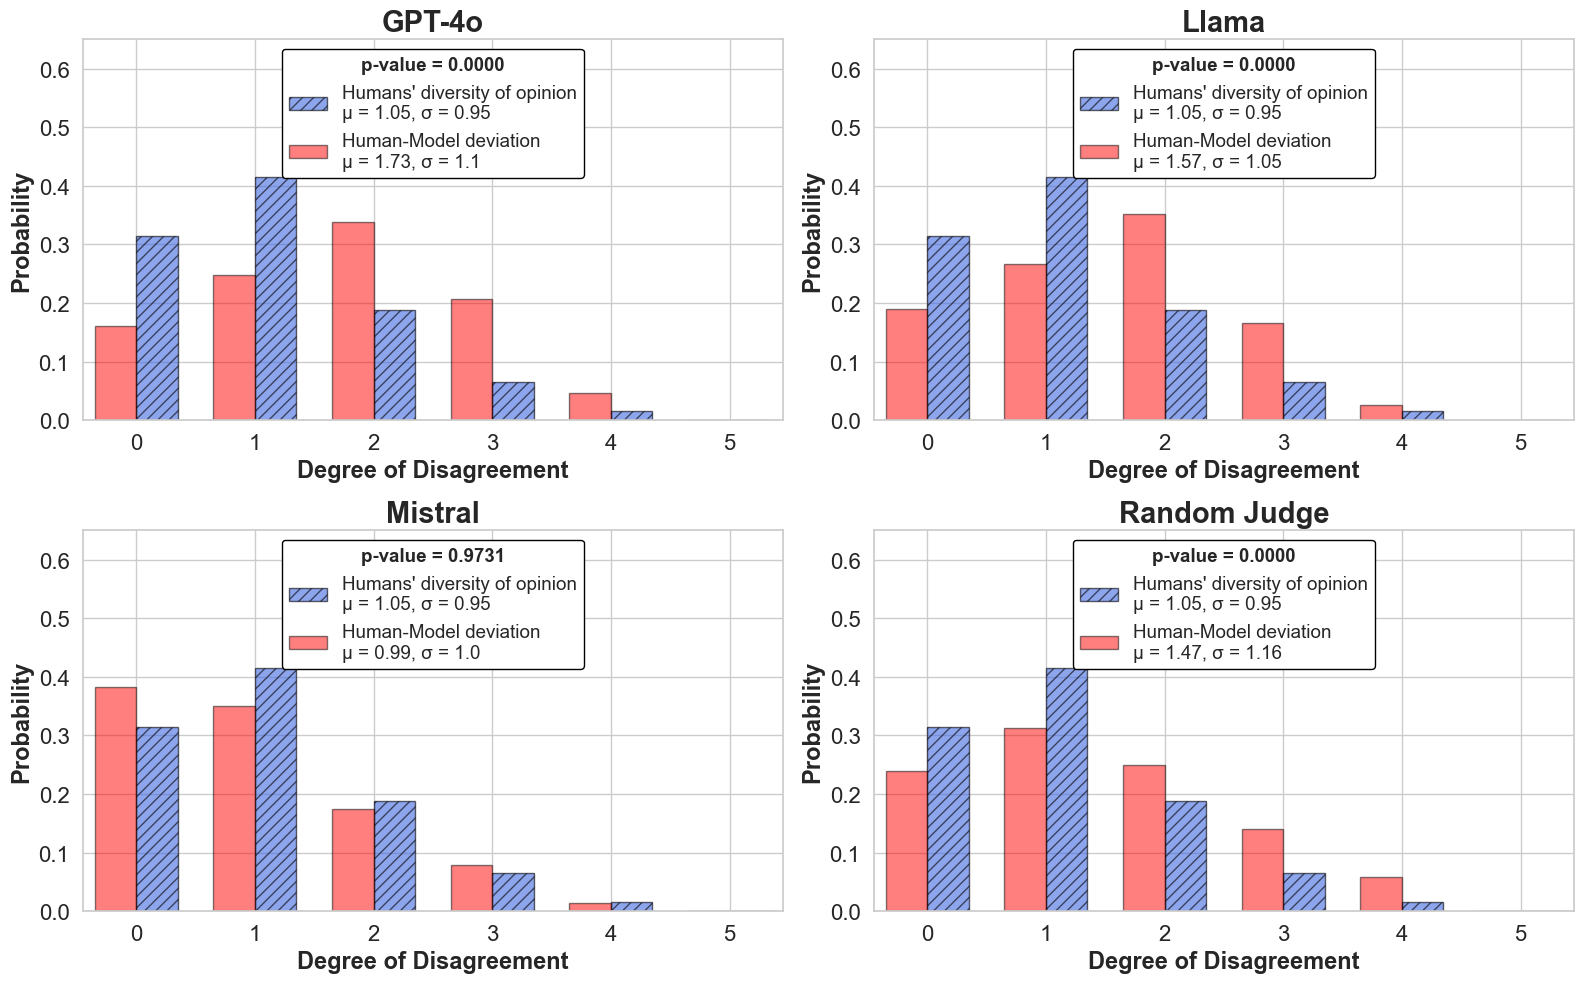

In [17]:
good_enough_informativeness.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.65,
    save_path="../figures/pdf/newsroom_informativeness_barplot.pdf"
)

### Relevance

✅ Figure saved as PDF → ../figures/pdf/newsroom_relevance_barplot.pdf


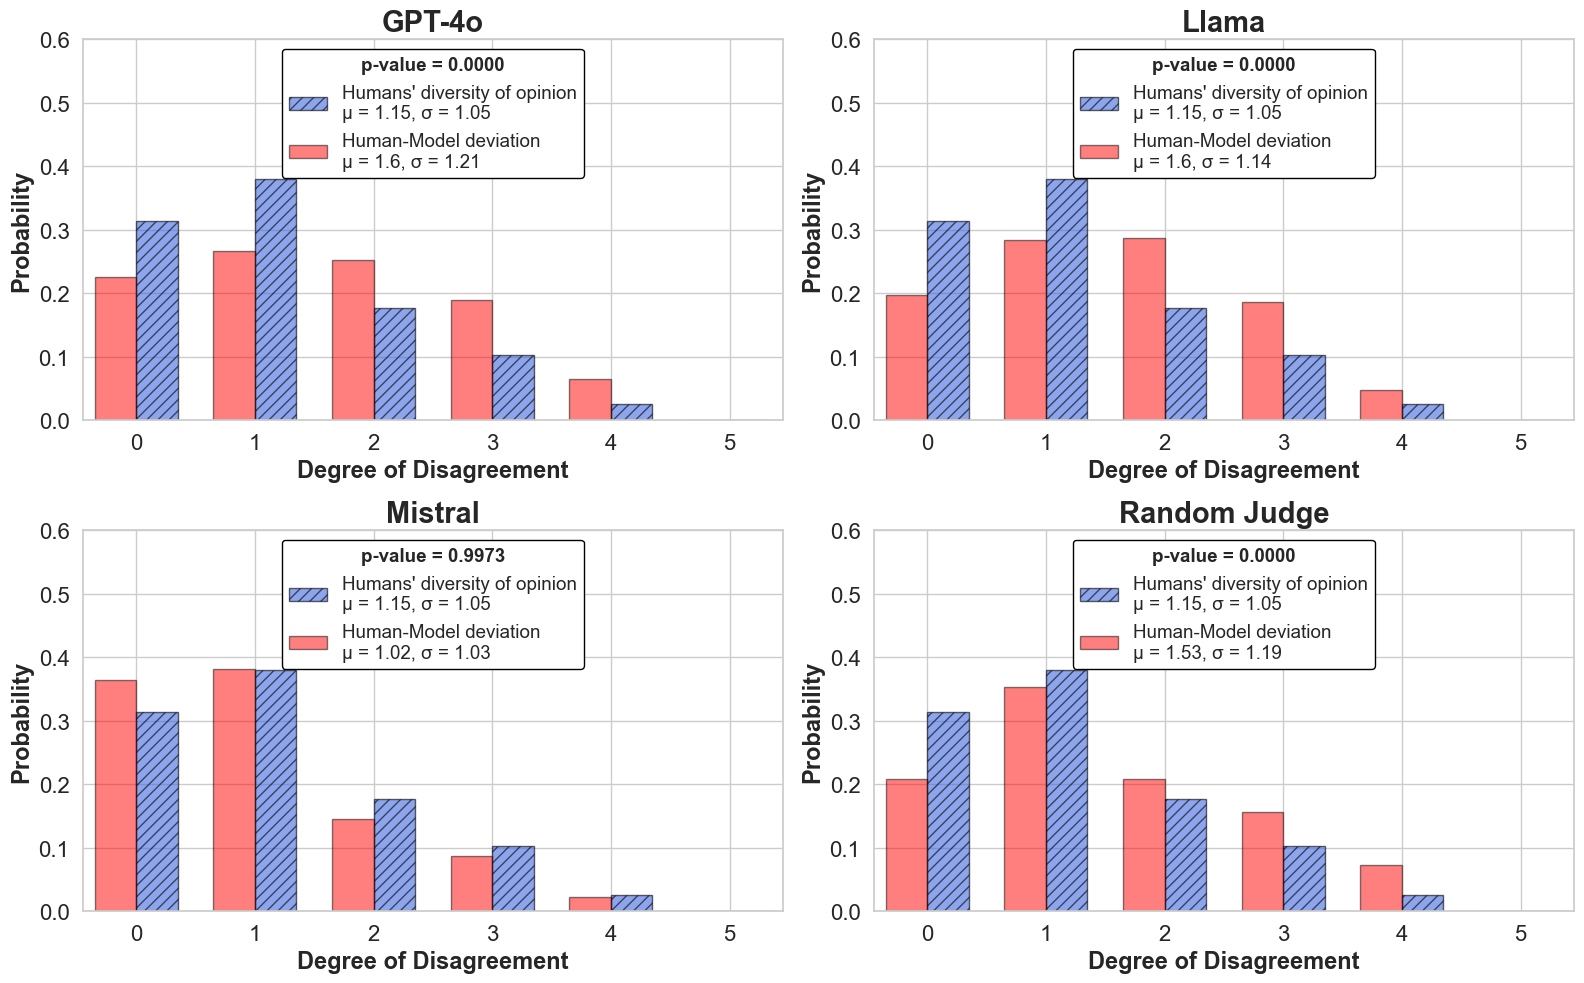

In [18]:
good_enough_relevance.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../figures/pdf/newsroom_relevance_barplot.pdf"
)

### Fluency

✅ Figure saved as PDF → ../figures/pdf/newsroom_fluency_barplot.pdf


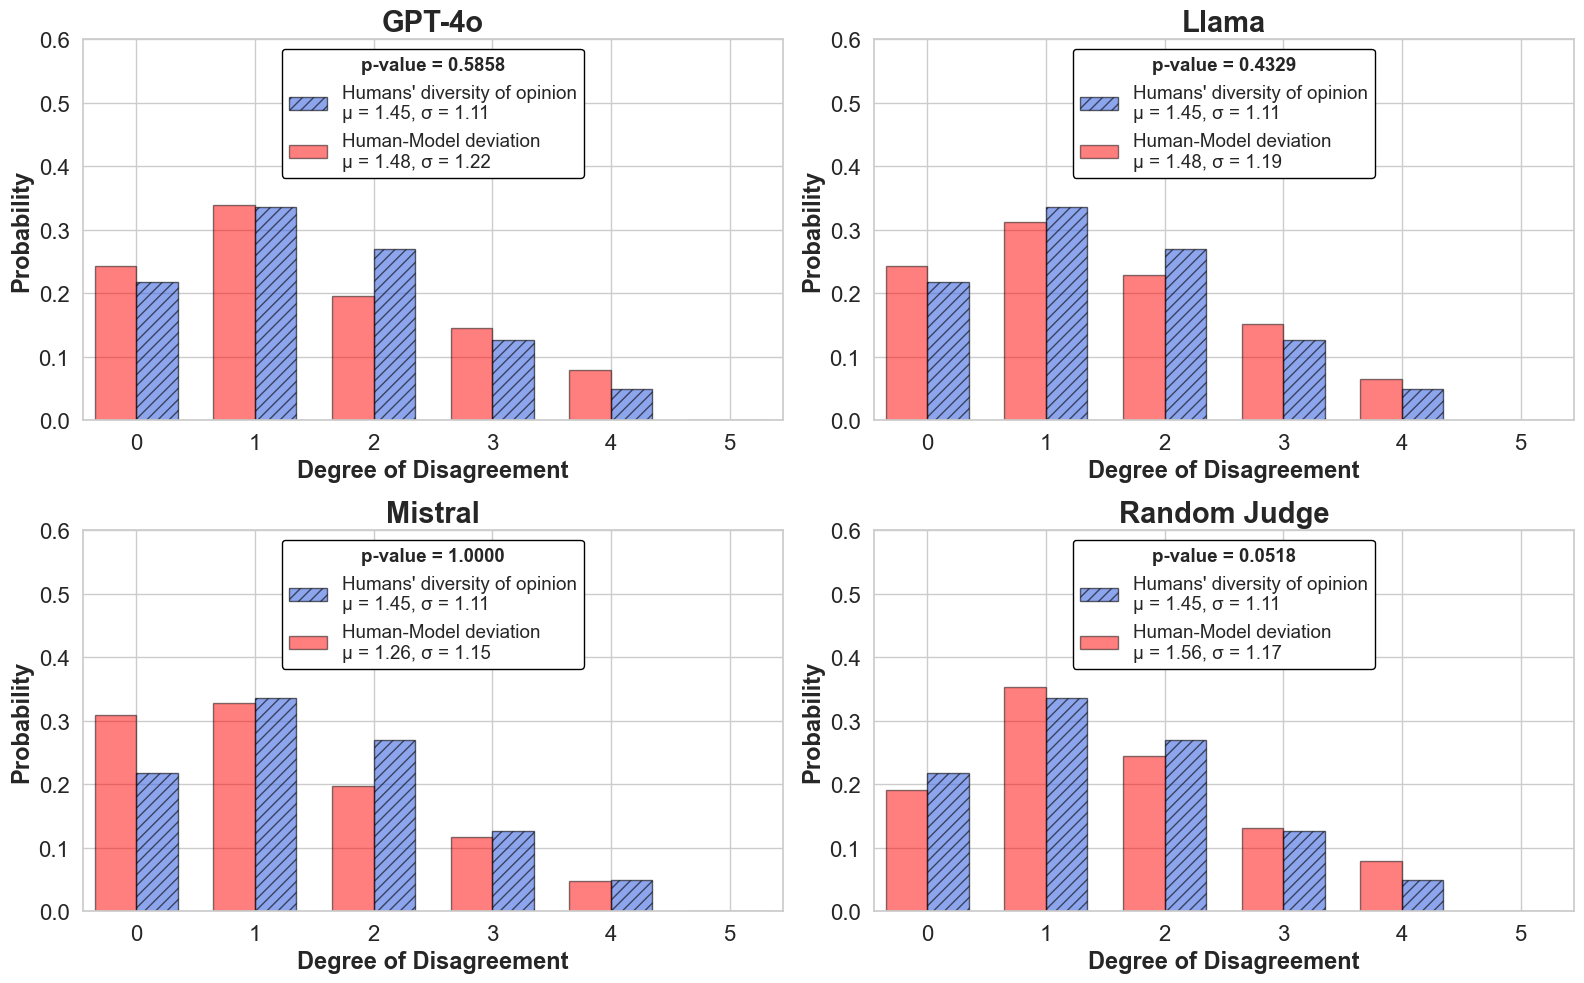

In [19]:
good_enough_fluency.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../figures/pdf/newsroom_fluency_barplot.pdf"
)

### Coherence

✅ Figure saved as PDF → ../figures/pdf/newsroom_coherence_barplot.pdf


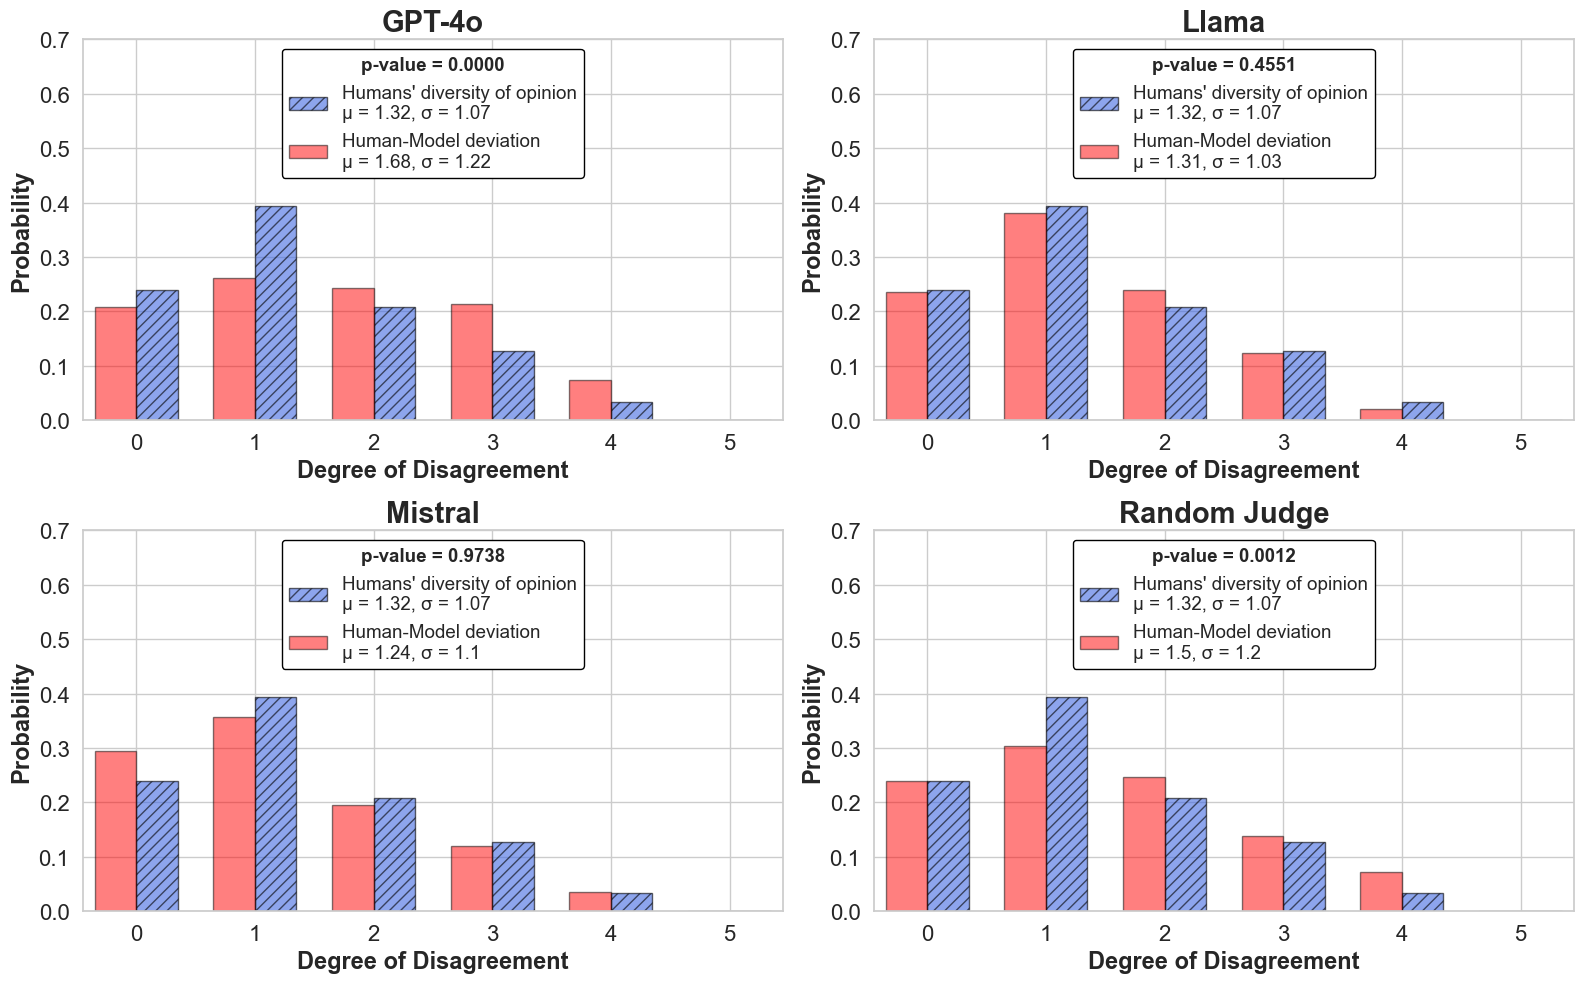

In [20]:
good_enough_coherence.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.7,
    save_path="../figures/pdf/newsroom_coherence_barplot.pdf"
)

## Robustness (Monte Carlo)

=== Running robustness analysis for INFORMATIVENESS ===


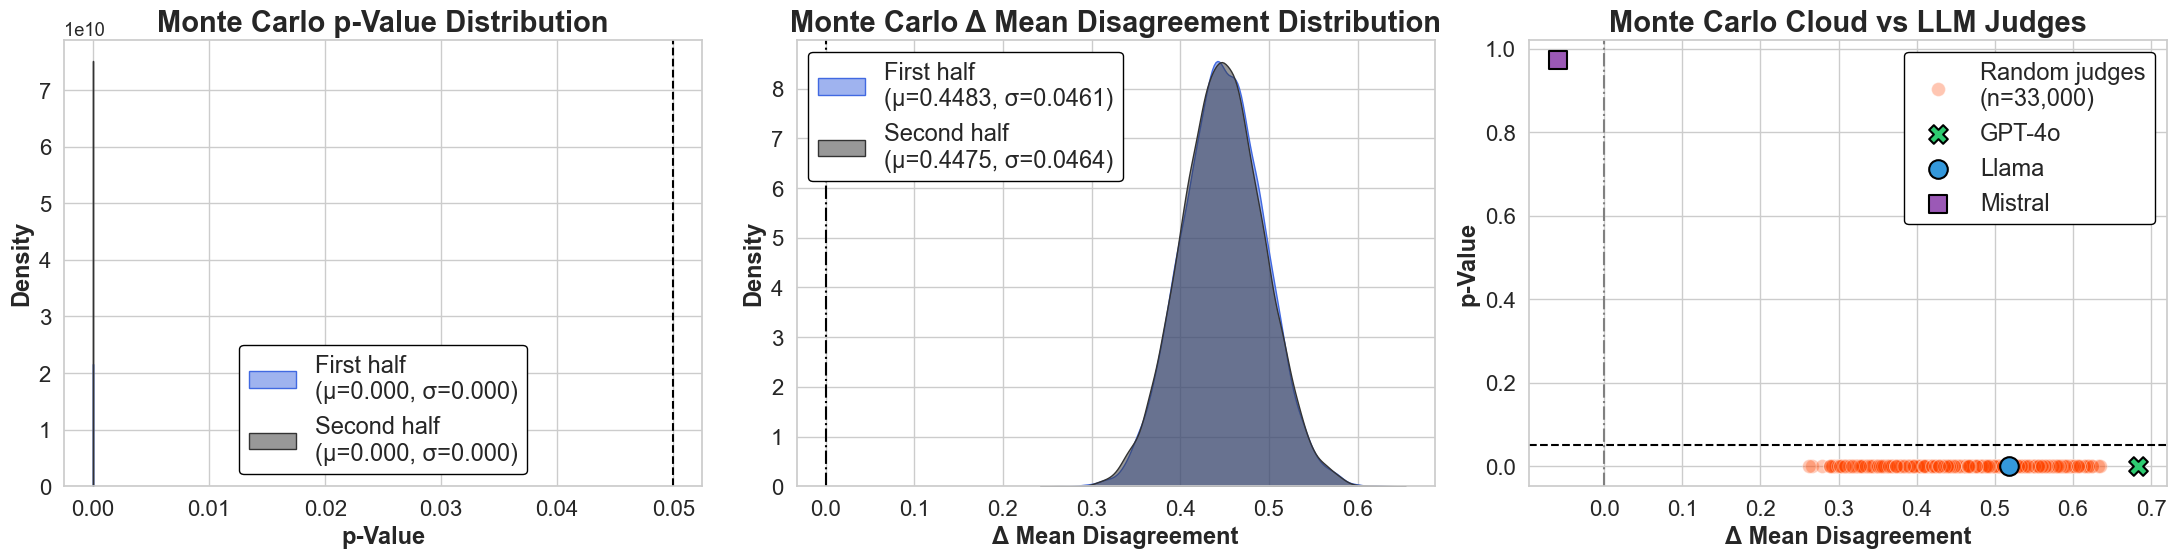

=== Running robustness analysis for RELEVANCE ===


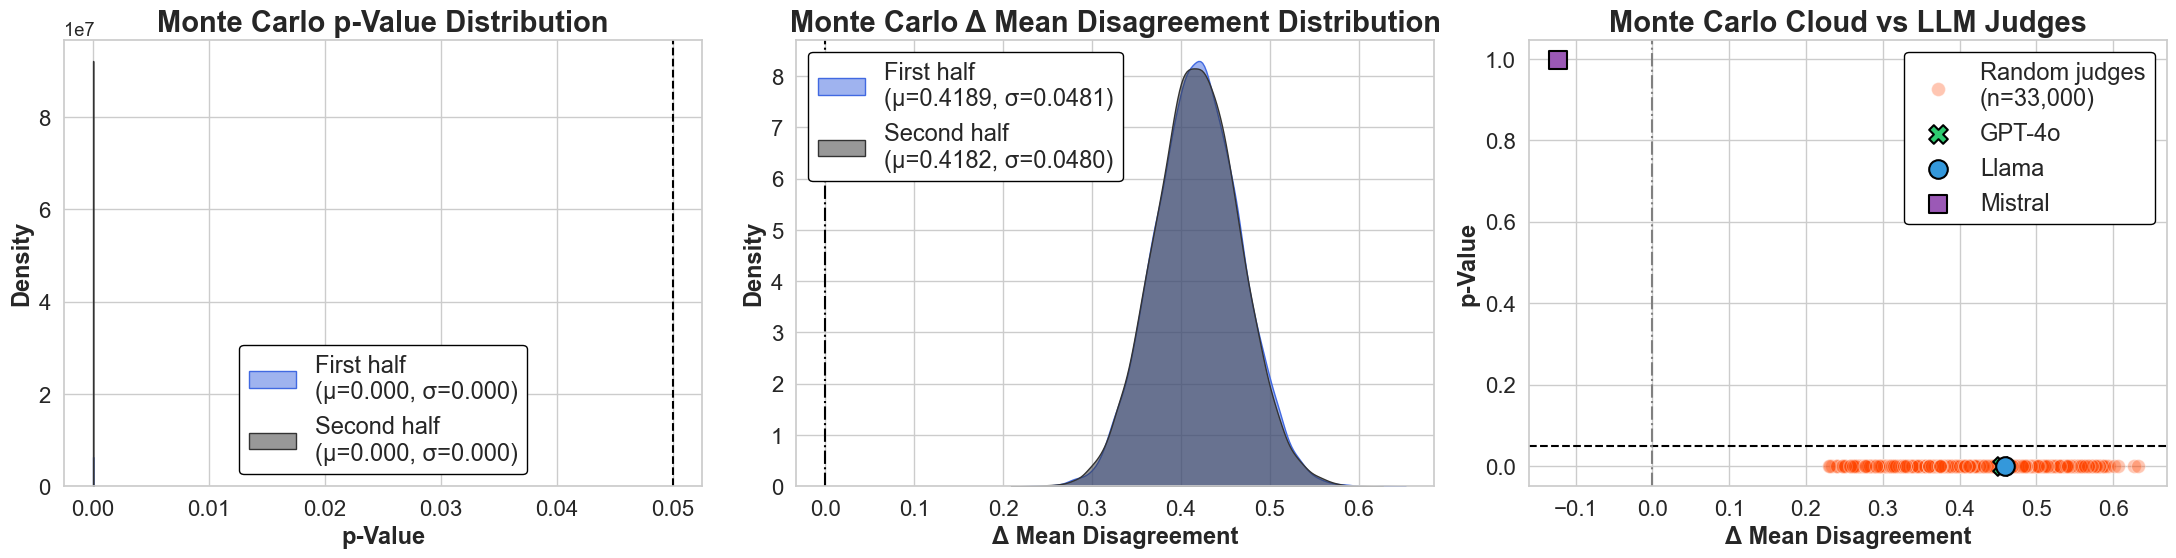

=== Running robustness analysis for FLUENCY ===


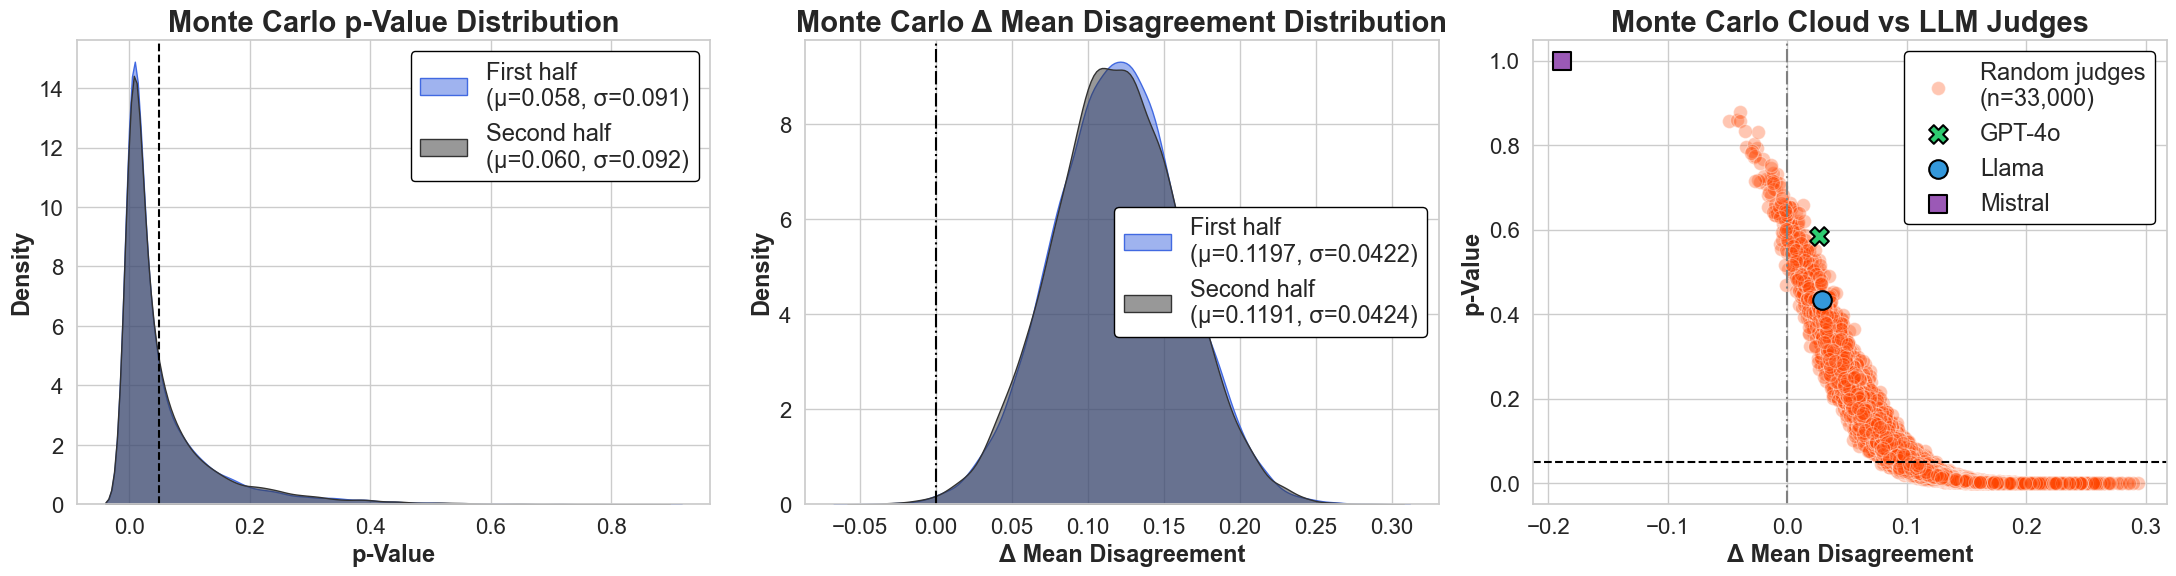

=== Running robustness analysis for COHERENCE ===


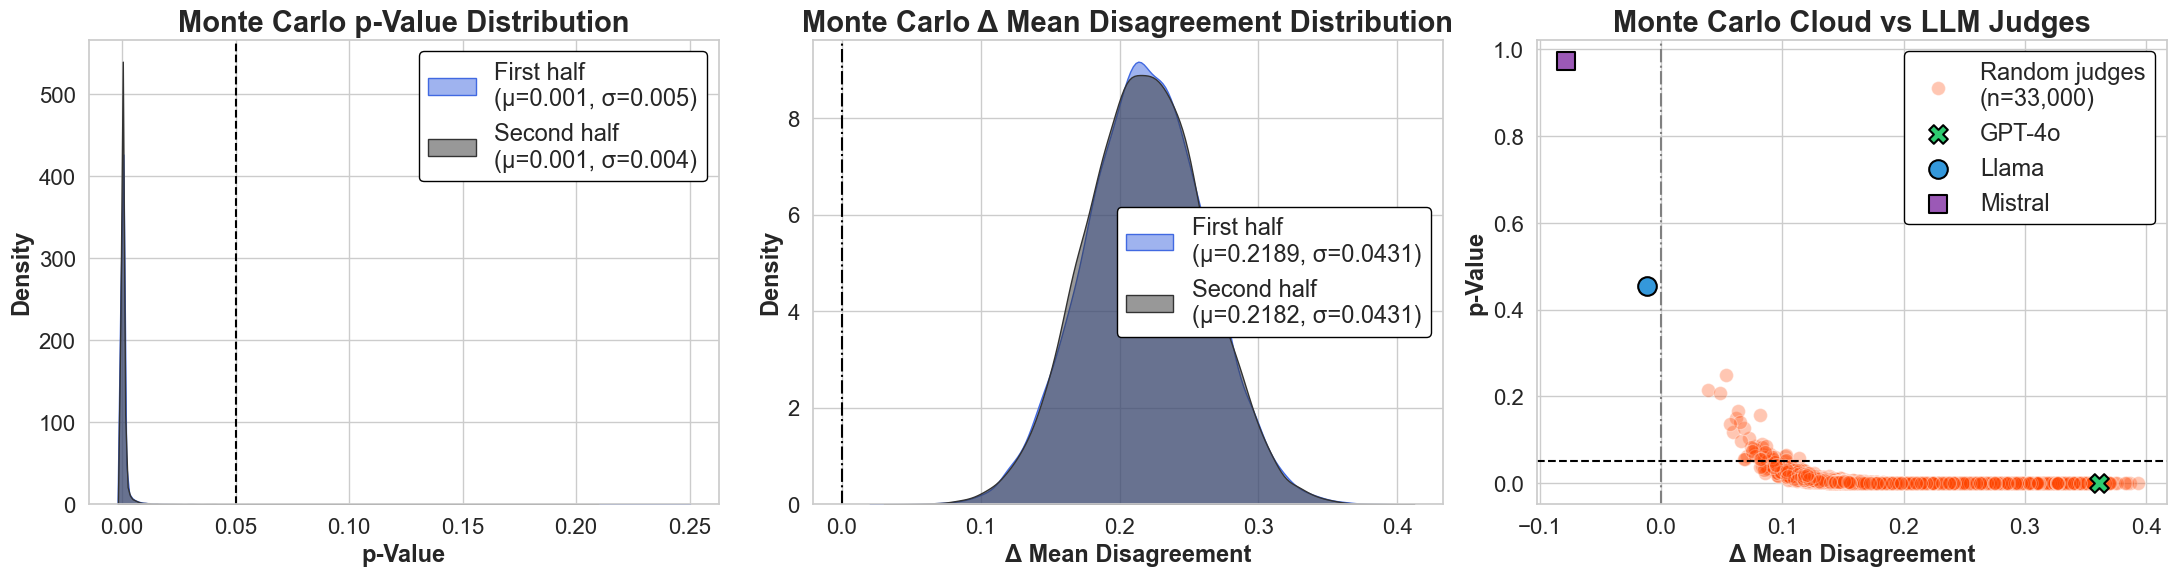

In [21]:
# Run robustness visualizations for each metric (all models in one figure)
models = ['GPT-4o', 'Llama', 'Mistral']

evaluators = {
    'informativeness': good_enough_informativeness,
    'relevance': good_enough_relevance,
    'fluency': good_enough_fluency,
    'coherence': good_enough_coherence
}

for metric_name, evaluator in evaluators.items():
    print(f"=== Running robustness analysis for {metric_name.upper()} ===")
    
    # Build list of LLM columns for this metric
    llm_cols = [f"{model}_{metric_name}_as_a_judge" for model in models]
    
    # Single call → single figure with all 3 LLMs in Panel C
    evaluator.plot_monte_carlo_robustness_multi(
        llm_cols=llm_cols,
        iterations=33_000,
        save_path=f"../figures/pdf/newsroom_monte_carlo_robustness_{metric_name}.pdf"
    )

## Human stability analysis

### Informativeness

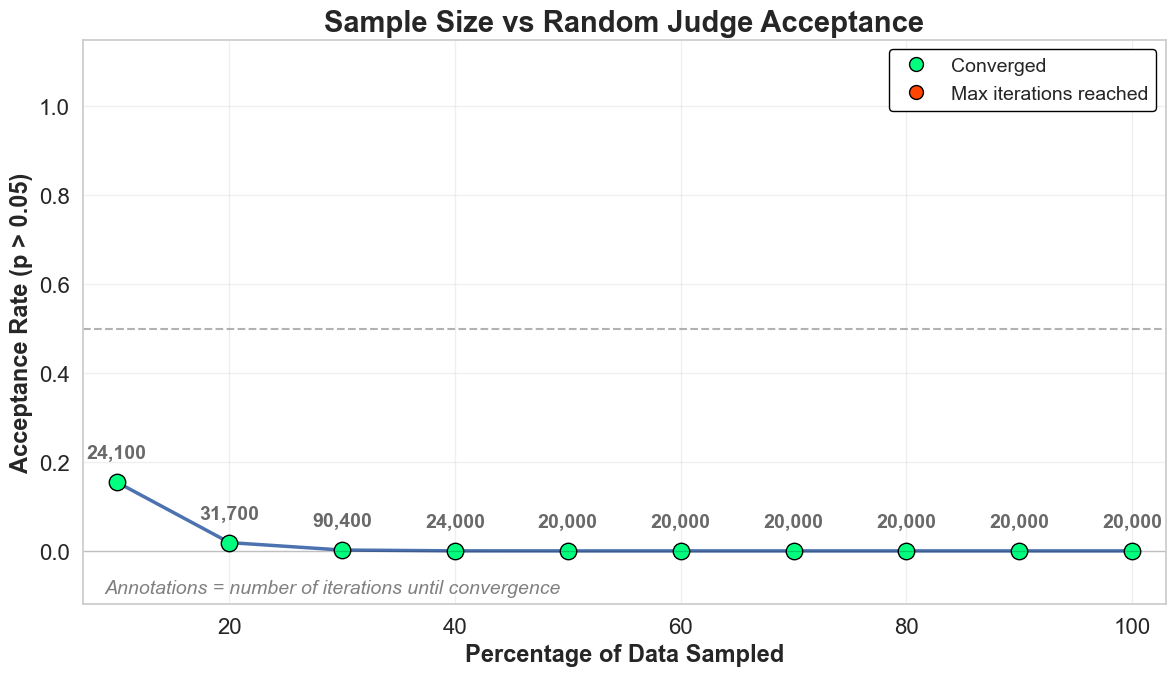

In [ ]:
good_enough_informativeness.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../figures/pdf/newsroom_human_stability_analysis_informativeness.pdf",
    parallel=True,
)

### Relevance

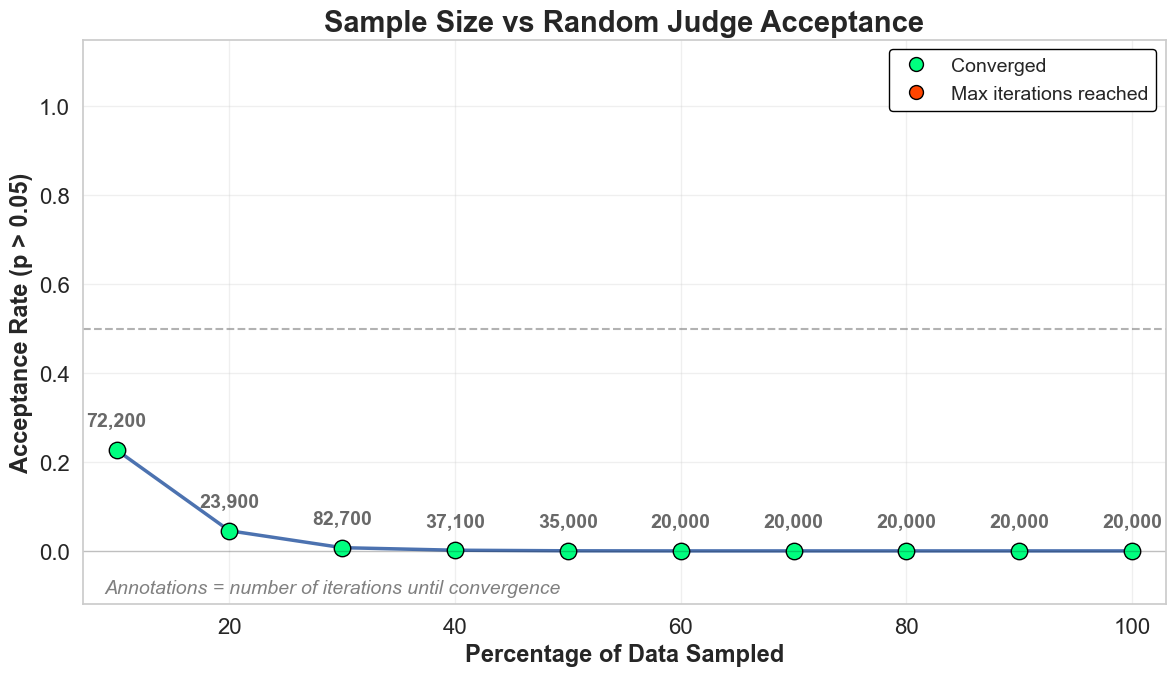

In [ ]:
good_enough_relevance.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../figures/pdf/newsroom_human_stability_analysis_relevance.pdf",
    parallel=True,
)

### Fluency

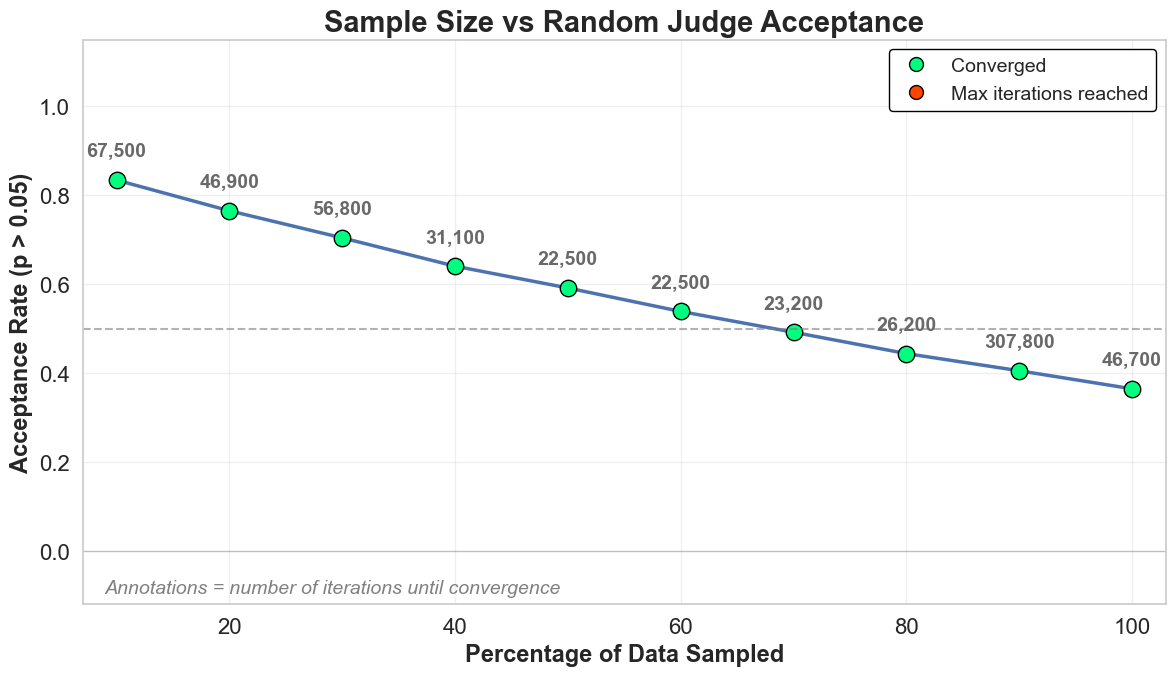

In [ ]:
good_enough_fluency.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../figures/pdf/newsroom_human_stability_analysis_fluency.pdf",
    parallel=True,
)

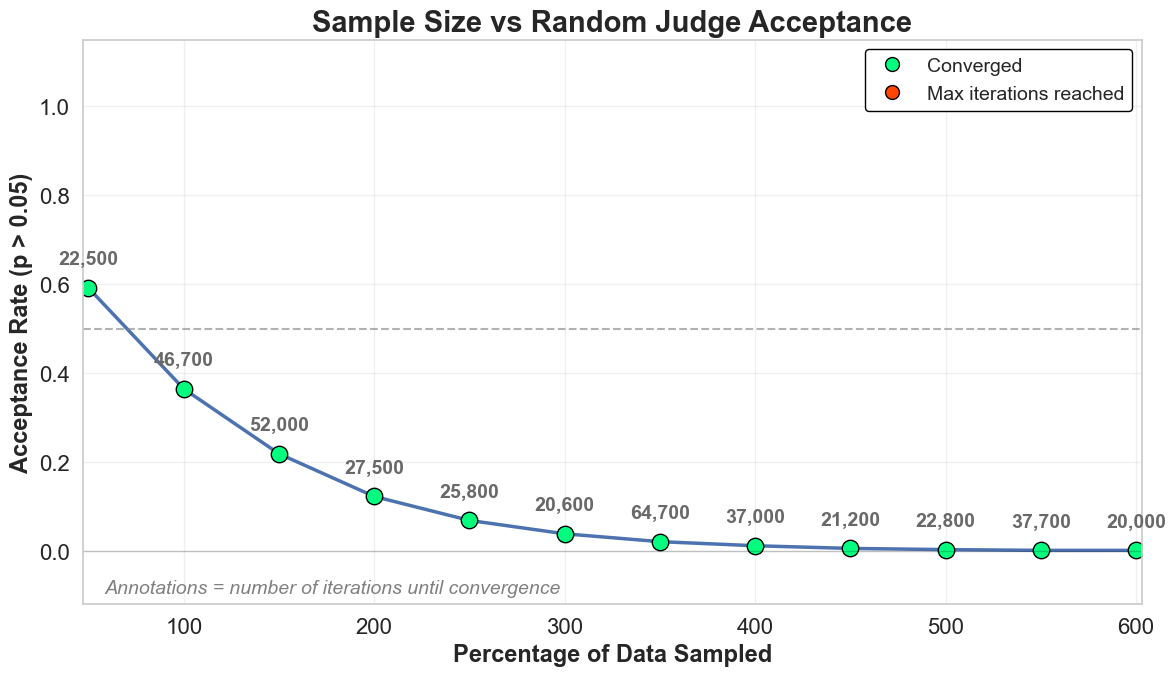

In [ ]:
good_enough_fluency.plot_human_stability_analysis(
    percentages=[
        50, 100, 150, 200, 
        250, 300, 350, 400,
        450, 500, 550, 600,
    ],
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../figures/pdf/newsroom_human_stability_analysis_fluency.pdf",
    parallel=True,
)

### Coherence

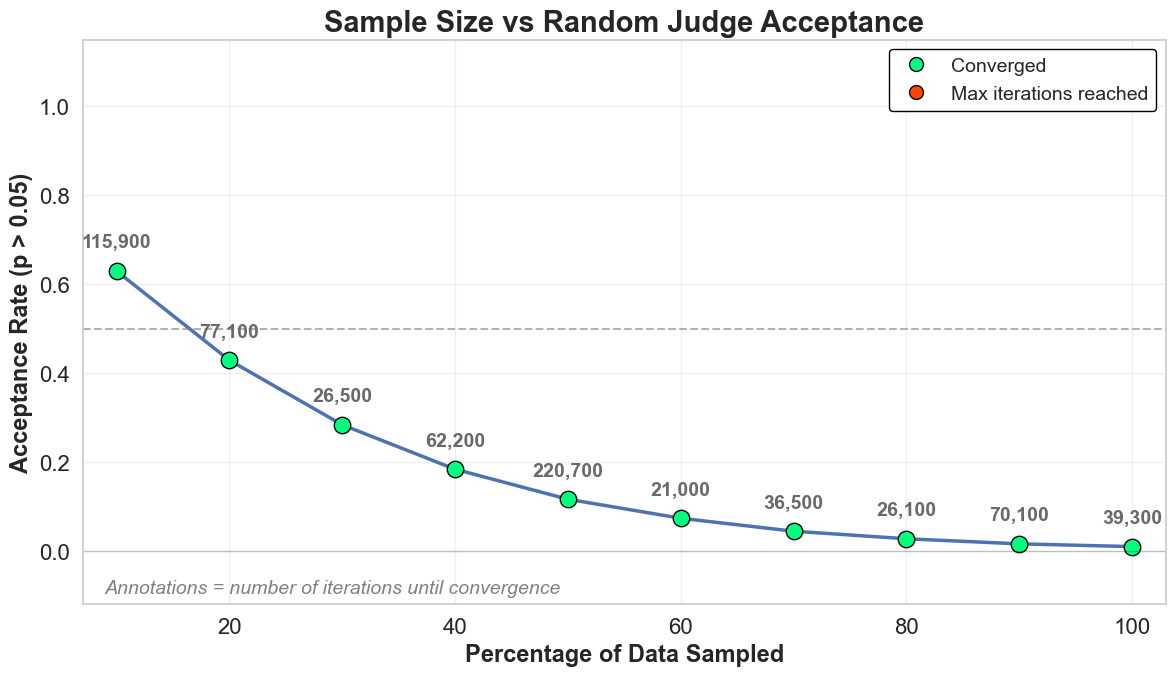

In [ ]:
good_enough_coherence.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../figures/pdf/newsroom_human_stability_analysis_coherence.pdf",
    parallel=True,
)

## LLM stability analysis


In [ ]:
models = ['GPT-4o', 'Llama', 'Mistral']

### Informativeness

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_informativeness.plot_llm_stability_analysis(
        llm_col=f"{model}_informativeness_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path=f"../figures/pdf/newsroom_{model}_stability_analysis_informativeness.pdf",
        parallel=True,
    )
    print("-"*99)

Model: GPT-4o


KeyboardInterrupt: 

### Relevance

Model: GPT


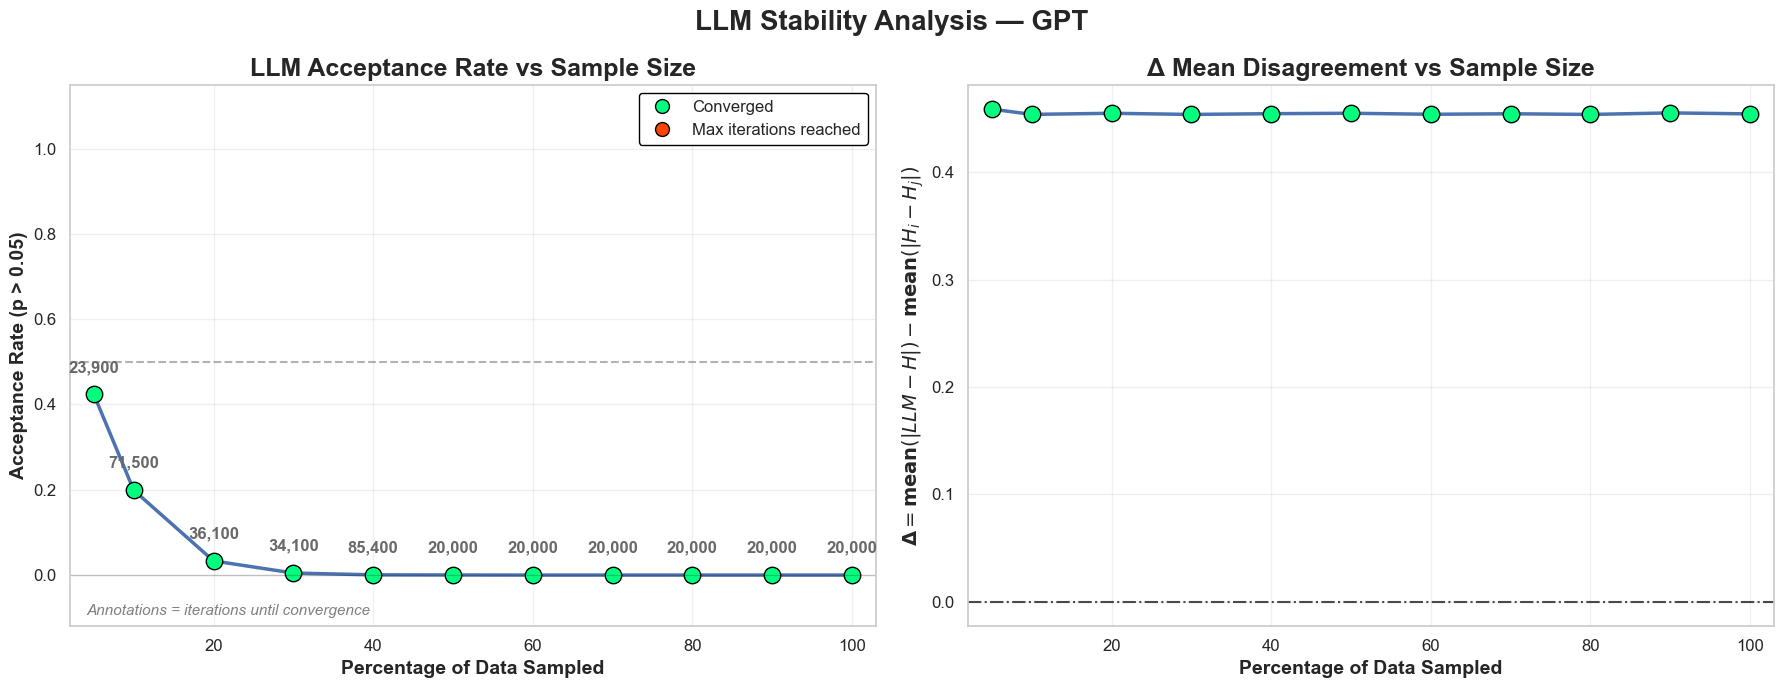

---------------------------------------------------------------------------------------------------
Model: LLAMA


KeyboardInterrupt: 

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_relevance.plot_llm_stability_analysis(
        llm_col=f"{model}_relevance_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path=f"../figures/pdf/newsroom_{model}_stability_analysis_relevance.pdf",
        parallel=True,
    )
    print("-"*99)

### Coherence

Model: GPT


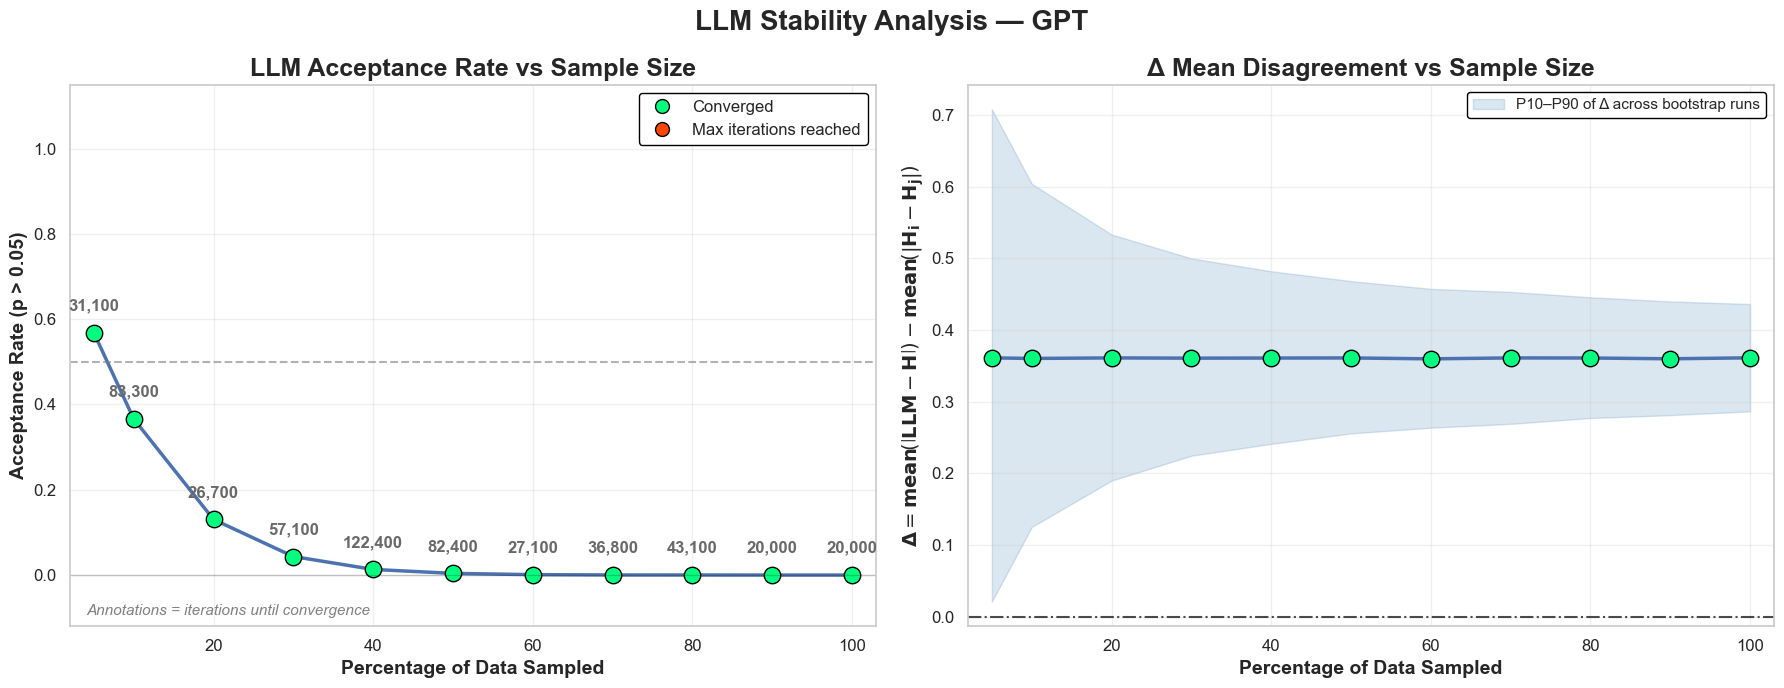

---------------------------------------------------------------------------------------------------
Model: LLAMA


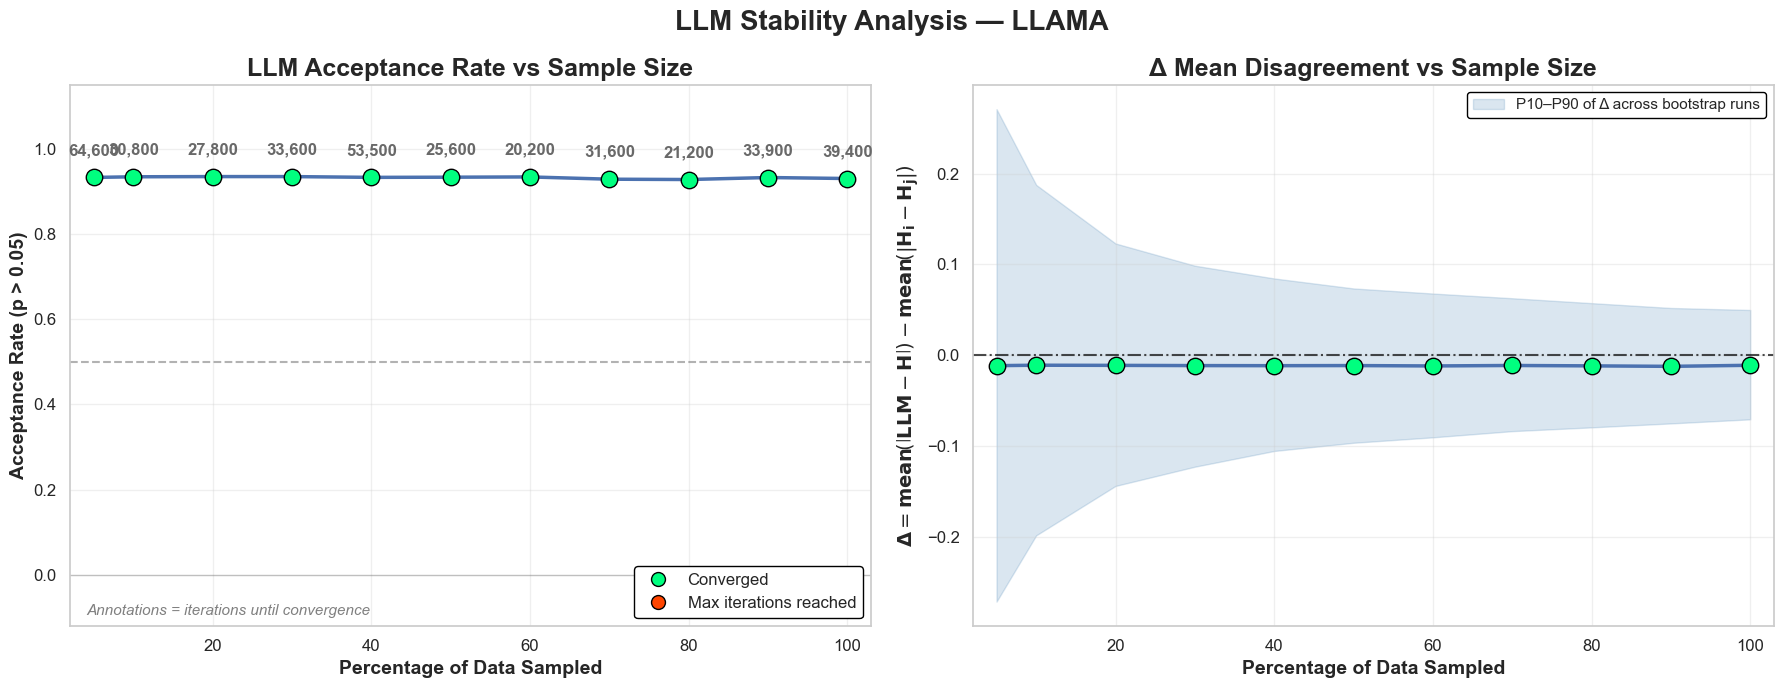

---------------------------------------------------------------------------------------------------
Model: MISTRAL


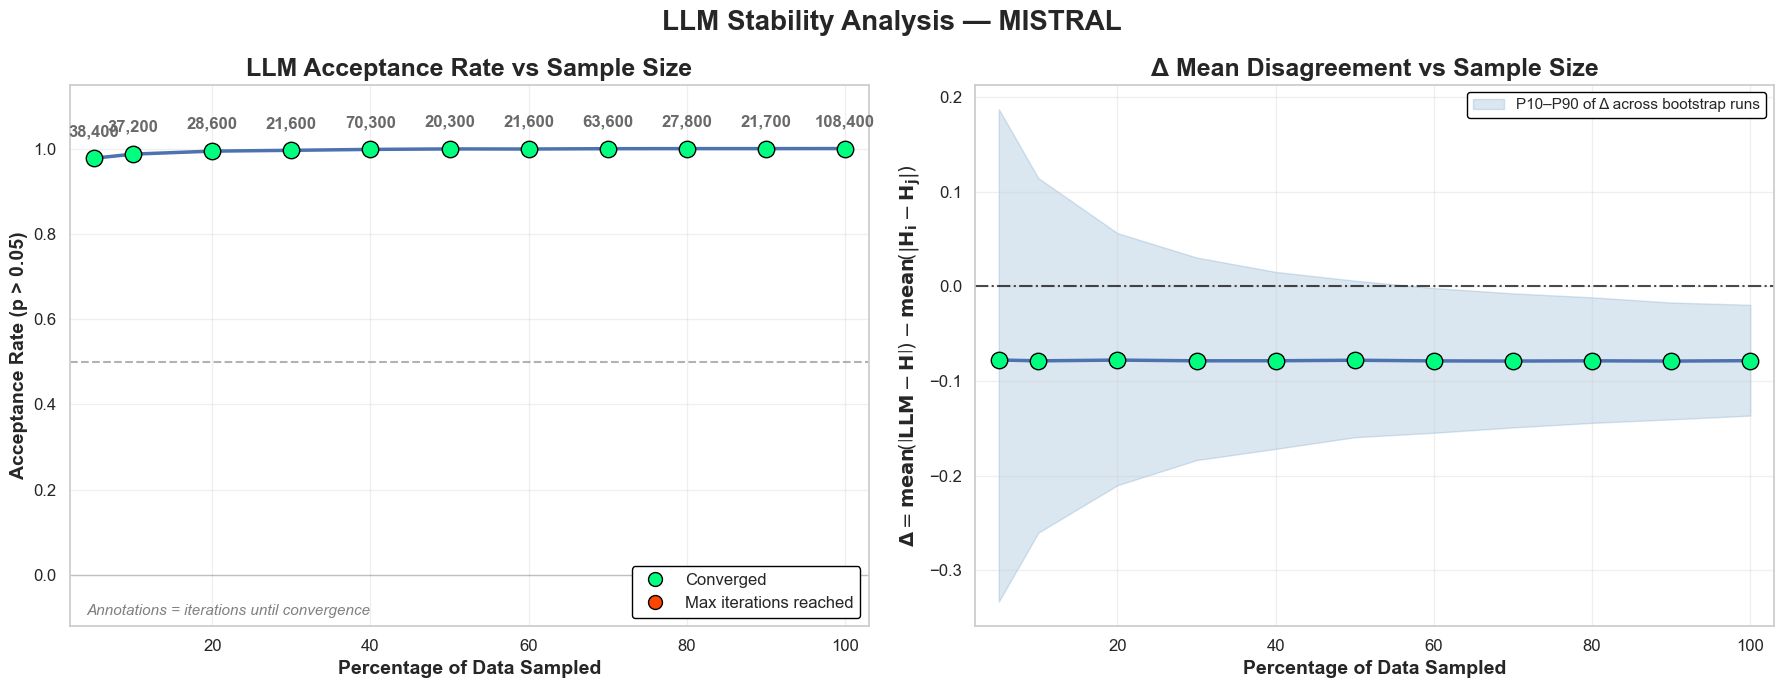

---------------------------------------------------------------------------------------------------


In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_coherence.plot_llm_stability_analysis(
        llm_col=f"{model}_coherence_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path=f"../figures/pdf/newsroom_{model}_stability_analysis_coherence.pdf",
        parallel=True,
    )
    print("-"*99)

### Fluency

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_fluency.plot_llm_stability_analysis(
        llm_col=f"{model}_fluency_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000, 
        save_path=f"../figures/pdf/newsroom_{model}_stability_analysis_fluency.pdf",
        parallel=True,
    )
    print("-"*99)

Model: GPT


KeyboardInterrupt: 